In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [2]:
data = sns.load_dataset("iris")
df = data.copy()
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
x = df.drop(columns=['species'])
y= df['species']

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: str

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [9]:
from sklearn.cluster import KMeans
kmean = KMeans(n_clusters=3)
label = kmean.fit_predict(x_scaled)
label

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 1, 2,
       2, 1, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1], dtype=int32)

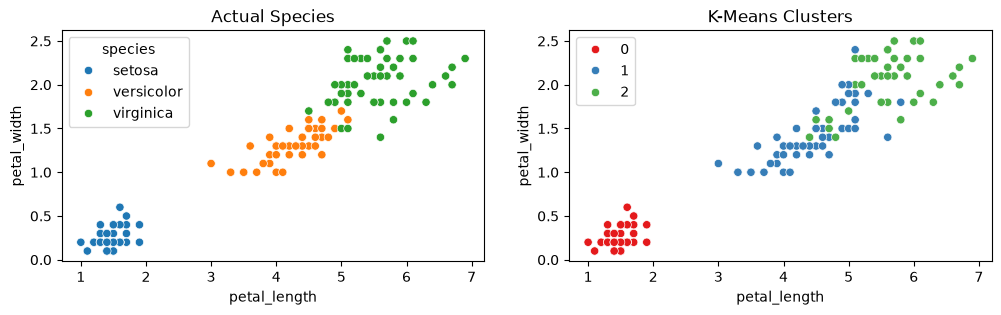

In [29]:
plt.figure(figsize=(12,3))

plt.subplot(1, 2, 1)
sns.scatterplot(x="petal_length", y="petal_width", data=df, hue=y)
plt.title("Actual Species")

plt.subplot(1, 2, 2)
sns.scatterplot(x="petal_length", y="petal_width", data=x, hue=label, palette="Set1")
plt.title("K-Means Clusters")

plt.show()

In [18]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
pca_df = pd.DataFrame(x_pca,columns=['pca1','pca2'])
pca_df.head()

,pca1,pca2
0,-2.264703,0.480027
1,-2.080961,-0.674134
2,-2.364229,-0.341908
3,-2.299384,-0.597395
4,-2.389842,0.646835


In [23]:
from sklearn.cluster import KMeans
kmean = KMeans(n_clusters=3)
pca_df['pca_cluster'] = kmean.fit_predict(pca_df)
pca_df.head()

,pca1,pca2,pca_cluster
0,-2.264703,0.480027,1
1,-2.080961,-0.674134,1
2,-2.364229,-0.341908,1
3,-2.299384,-0.597395,1
4,-2.389842,0.646835,1


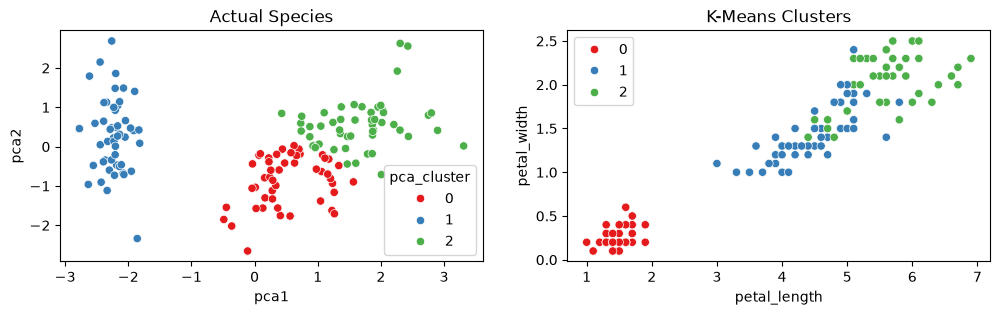

In [28]:
plt.figure(figsize=(12,3))

plt.subplot(1, 2, 1)
sns.scatterplot(x= "pca1", y= "pca2", data= pca_df, hue='pca_cluster',palette="Set1")
plt.title("Actual Species")

plt.subplot(1, 2, 2)
sns.scatterplot(x="petal_length", y="petal_width", data=x, hue=label, palette="Set1")
plt.title("K-Means Clusters")

plt.show()